<a href="https://colab.research.google.com/github/Thaizalu/Data_Science/blob/main/Churn_Prediction_para_uma_empresa_de_Telecomunica%C3%A7%C3%B5es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
<img alt="Colaboratory logo" width="100%" src="https://github.com/Thaizalu/Imagens_Dataset/blob/50366d07445ea498afae09257292aed08b138c92/churn-prediction-1920-614.png?raw=true">

#**Churn Prediction para uma empresa de Telecomunicações**
*by [Thaiza Ludmila](https://www.linkedin.com/in/thaizalu/)*   

---

A previsão de churn (ou evasão) é uma aplicação da ciência de dados em diversas indústrias. Churn refere-se ao fenômeno em que clientes deixam de usar os serviços de uma empresa, optando por cancelar suas assinaturas ou migrar para um concorrente. Identificar e prever quais clientes estão propensos a churn é vital para as empresas, pois a retenção de clientes existentes geralmente é mais custo-efetiva do que adquirir novos.

<p align=center>
<img src="https://user-images.githubusercontent.com/81787449/132009565-9b5f6f66-adfd-4b55-b1b7-754ca82da931.png" width="60%"></p>

O objetivo de um modelo de previsão de churn é utilizar dados históricos dos clientes para identificar padrões e sinais que antecedem a evasão. Esses dados podem incluir informações demográficas, histórico de uso dos serviços, interações com o atendimento ao cliente, entre outros. Utilizando técnicas de machine learning, é possível criar modelos preditivos que estimam a probabilidade de um cliente específico deixar a empresa dentro de um determinado período.

Ao aplicar a previsão de churn, empresas de telecomunicações, por exemplo, podem adotar medidas proativas para reter clientes de alto risco, oferecendo promoções, melhorando o atendimento ou ajustando seus serviços para atender melhor às necessidades dos clientes. Dessa forma, a previsão de churn não apenas ajuda a reduzir a taxa de evasão, mas também melhora a satisfação e a lealdade dos clientes, impactando positivamente a receita e a sustentabilidade da empresa a longo prazo.

Uma boa análise exploratória pode nos fornecer insights interessantes!

* Qual o perfil da pessoa que cancela nosso atendimento? (Sexo? Casado? Filhos?)
* Que tipo de serviços podem indicar mais cancelamentos?
* Pessoas com diferentes tipos de métodos de pagamento poderiam ser retidas facilmente?
* Que tipo de serviço posso sugerir para fidelizar meu cliente?

Tentaremos responder a perguntas de negócios antes de prever modelos. Depois disso, podemos aplicar algumas previsões para evitar o churn e fornecer à nossa empresa um entendimento ponta a ponta desde a análise exploratória até a modelagem de técnicas de aprendizado de máquina!

Neste script, percorreremos uma abordagem simples para construir uma análise exploratória eficaz, preparação de dados, treinar, ajustar e avaliar alguns modelos de aprendizado de máquina.

## Aquisição dos Dados

Os dados utilizados neste projeto foram originalmente disponibilizados na [plataforma de ensino da IBM Developer](https://developer.ibm.com/technologies/data-science/patterns/predict-customer-churn-using-watson-studio-and-jupyter-notebooks/#), e tratam de um problema típico de uma companhia de telecomunicações. O *dataset* completo pode ser encontrado [neste link](https://raw.githubusercontent.com/carlosfab/dsnp2/master/datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv).

Apesar de não haver informações explícitas disponíves, os nomes das colunas permitem um entendimento a respeito do problema.

In [1]:
# instalando os pacotes
!pip install scikit-plot -q
!pip install imbalanced-learn -q

In [2]:
# importando a função simplefilter do módulo warnings da biblioteca padrão do Python
from warnings import simplefilter
# ignorando todos os future warnings
simplefilter(action='ignore', category=FutureWarning)

In [3]:
# importar os pacotes necessários
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, confusion_matrix, classification_report
from scikitplot.metrics import plot_confusion_matrix, plot_roc
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

In [4]:
# configurando a aleatoriedade do numpy (random seed)
np.random.seed(42)

In [5]:
# importar os dados
DATA_PATH = "https://raw.githubusercontent.com/carlosfab/dsnp2/master/datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(DATA_PATH)

# ver as 5 primeiras entradas
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## **Dicionário dos Dados**

Os dados de *churn* de clientes para uma empresa de telecomunicações hipotética possuem os seguintes atributos:

* customerID - Identificador exclusivo do cliente
* gender - Gênero do Cliente - ['Female' 'Male']
* SeniorCitizen - Se o cliente é idoso ou não (1,0)
* Partner - Se o cliente tem um parceiro ou não; aqui será considerado se ele é casado ou não - ['No' 'Yes']
* Dependents - Se o cliente tem dependentes - ['No' 'Yes']
* Tenure - Total de tempo de contrato em meses
* PhoneService - Se o cliente possui atendimento telefônico ou não - ['No' 'Yes']
* MultipleLines - Se o cliente tem várias linhas ou não - ['No' 'No phone service' 'Yes']
* InternetService - Serviço de internet - ['No' 'No internet service' 'Yes']
* OnlineSecurity - Se o cliente tem segurança online ou não - ['No' 'No internet service' 'Yes']
* OnlineBackup - Se o cliente tem backup online ou não - ['No' 'No internet service' 'Yes']
* DeviceProtection - Se o cliente tem proteção de dispositivo ou não - ['No' 'No internet service' 'Yes']
* TechSupport - Se o cliente tem suporte técnico ou não - ['No' 'No internet service' 'Yes']
* StreamingTV - Se o cliente tem streaming de TV ou não - ['No' 'No internet service' 'Yes']
* StreamingMovies - Se o cliente tem streaming de filmes ou não - ['No' 'No internet service' 'Yes']
* Contract - tipo de contrato - ['Month-to-month' 'One year' 'Two year']
* PaperlessBilling - Se o cliente tem faturamento sem papel ou não - ['No' 'Yes']
* PaymentMethod - Forma de pagamento - ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
* MonthlyCharges - O valor cobrado mensalmente do cliente
* TotalCharges - O valor total cobrado do cliente
* Churn - Se o cliente cancelou ou não - ['No' 'Yes']

## **Análise Exploratória dos Dados**

Para iniciar nossa análise exploratória, é preciso examinar a distribuição dos dados, verificar a presença de outliers e anomalias do dataset. Está é uma etapa importante de qualquer análise estratégica e ajudará a entender melhor o dataset.

In [6]:
# conhecendo o tamanho do dataset importado
print('Dimensão do dataset ')
print('Entradas:\t{}'.format(df.shape[0]))
print('Variáveis:\t{}'.format(df.shape[1]))

Dimensão do dataset 
Entradas:	7043
Variáveis:	21


## **Recursos e Tipos de Dados**

Aqui será verificado  a quantidade de dados ausentes, os nomes das colunas, os tipos de variáveis por coluna e os valores únicos por coluna, sendo esta última, que auxiliará na identificação de variáveis potencialmente categóricas.

In [7]:
print("Dados ausentes (total):\t{}\n".format(df.isnull().sum().values.sum()))
print(df.isnull().sum() / df.shape[0])
print("\nNomes dos atributos:\n{}\n".format(df.columns.values))
print("Valores únicos (por coluna):\n{}\n".format(df.nunique()))
print("Tipos de Variáveis (por coluna)\n{}".format(df.dtypes))

Dados ausentes (total):	0

customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

Nomes dos atributos:
['customerID' 'gender' 'SeniorCitizen' 'Partner' 'Dependents' 'tenure'
 'PhoneService' 'MultipleLines' 'InternetService' 'OnlineSecurity'
 'OnlineBackup' 'DeviceProtection' 'TechSupport' 'StreamingTV'
 'StreamingMovies' 'Contract' 'PaperlessBilling' 'PaymentMethod'
 'MonthlyCharges' 'TotalCharges' 'Churn']

Valores únicos (por coluna):
customerID          7043
gender                 2
SeniorCitizen          2
Partner            

Veja algumas observações que merecem destaque, observadas nessa fase inicial de awareness:

* A coluna `costumerID` não agrega nenhuma informação, pois se trata de um identificador única para cada cliente.
* A variável alvo está na coluna `Churn`, indicando a situação de churn.
* A coluna `TotalCharges` deveria ser um `float`, mas está como `string`.
    * Apesar de não termos detectado nenhum valor ausente, existem algumas strings que representam sim valores ausentes.
* Várias features precisam ser codificadas para valores numéricos.
    * Há várias features binárias, incluindo nossa variável alvo, ou com múltiplos valores, cada um representando uma categoria.

* A variável `SeniorCitizen`, conforme visto nos valores únicos, é uma coluna binária, sendo necessária sua conversão de int64 para object.

In [8]:
# converter coluna TotalCharges para float
#df["TotalCharges"].astype('float32')

Quando tentamos converter as strings da coluna `TotalCharges`, acabamos identificando um erro.

O que aconteceu na verdade, foi que os supostos dados ausentes foram lançados como a string `""`. Quando tentamos `float("")`, o interpretador retorna um erro.

Assim, para conseguir converter adequadamente, foi criado um método para lidar com essa exceção. Ao final, foi identificado que dados ausentes foram encontrados, e substituído pelo valor da mediana da coluna.



## **Checando valores ausentes**

Antes de checar os valores ausentes, será substituído os espaços em branco que este dataset possa ter

In [9]:
# Identificando o percentual de valores vazios de todo dataset em ordem descendente
(df.isnull().sum() / df.shape[0]).sort_values(ascending=False)

customerID          0.0
DeviceProtection    0.0
TotalCharges        0.0
MonthlyCharges      0.0
PaymentMethod       0.0
PaperlessBilling    0.0
Contract            0.0
StreamingMovies     0.0
StreamingTV         0.0
TechSupport         0.0
OnlineBackup        0.0
gender              0.0
OnlineSecurity      0.0
InternetService     0.0
MultipleLines       0.0
PhoneService        0.0
tenure              0.0
Dependents          0.0
Partner             0.0
SeniorCitizen       0.0
Churn               0.0
dtype: float64

In [10]:
# outro método para converter a coluna de string para número, usando o coerce
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [11]:
# Verificando os dados ausentes
print(f"A coluna TotalCharges possui {df['TotalCharges'].isnull().sum()} valores vazios.")

A coluna TotalCharges possui 11 valores vazios.


In [12]:
# Prenchendo dados faltantes com a mediana
TotalChargesMedian = df.TotalCharges.median()
df["TotalCharges"].fillna(TotalChargesMedian, inplace=True)

In [13]:
# Verificando os dados ausentes
print(f"A coluna TotalCharges possui {df['TotalCharges'].isnull().sum()} valores vazios.")

A coluna TotalCharges possui 0 valores vazios.


In [14]:
# convertendo a coluna SeniorCitizen em string
df['SeniorCitizen'] = df['SeniorCitizen'].astype(object)

Apesar deste dataset ser composto majoritariamente por variáveis binárias ou categóricas, é possível ver abaixo, pelo método describe, que não há indícios da presença de outliers.

In [15]:
# Resumo Estatístico sobre as variáveis categóricas
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.916928
std,24.559481,30.090047,2265.270398
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,402.225000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


Analisando o boxplot para as colunas MonthlyCharges e TotalCharges, perceba como a distribuição dos valores reforça essa hipótese. O threshold padrão não acusou nenhum plot fora dos limites superior e inferior.

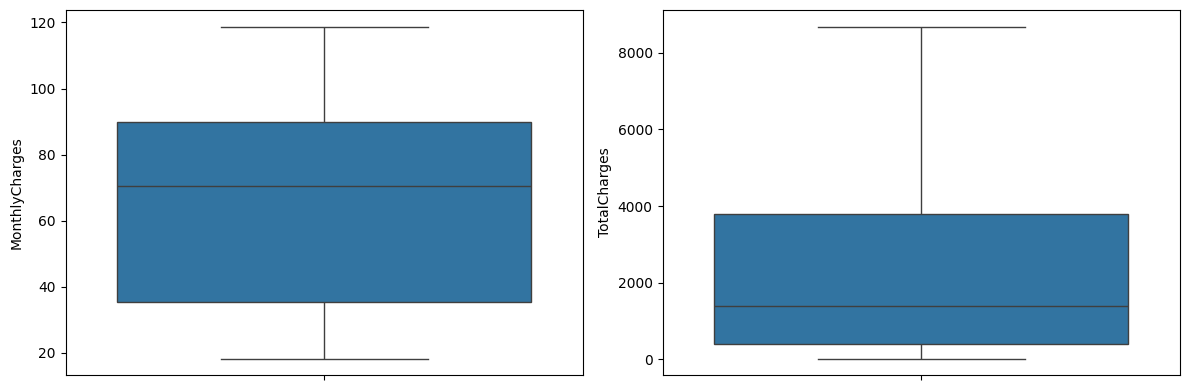

In [16]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
sns.boxplot(df['MonthlyCharges'], ax=ax[0])
sns.boxplot(df['TotalCharges'], ax=ax[1])
plt.tight_layout()

A variável tenure está relacionada ao tempo que um cliente permance assinando determinado serviço. Em outras palavras, pode-se dizer que é um indicativo de fidelidade.

Apesar de não haver nenhuma documentação, presume-se que a unidade de tempo utilizada é "mês".

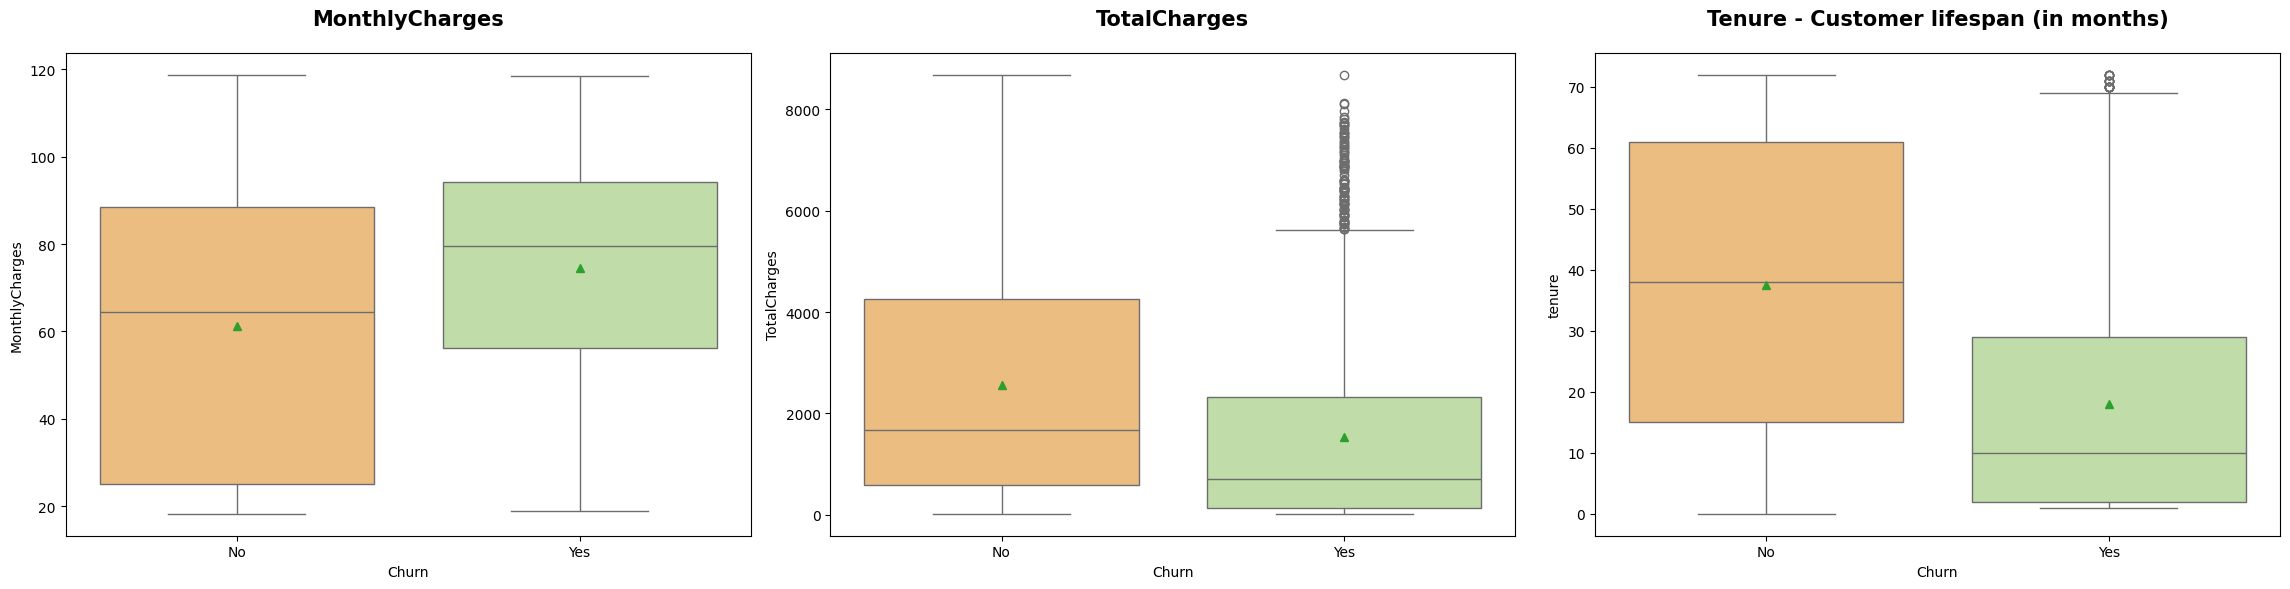

In [17]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(23, 6))

# Use the 'x' and 'y' arguments to specify the data for the boxplot
sns.boxplot(x=df.Churn, y=df['MonthlyCharges'], showmeans=True, ax=ax[0], palette="Spectral")
ax[0].set_title('MonthlyCharges',fontsize=15, fontweight='bold',pad=20)

sns.boxplot(x=df.Churn, y=df['TotalCharges'], showmeans=True, ax=ax[1],palette="Spectral")
ax[1].set_title('TotalCharges',fontsize=15, fontweight='bold',pad=20)

sns.boxplot(x=df.Churn, y=df.tenure, showmeans=True, ax=ax[2],palette="Spectral")
ax[2].set_title('Tenure - Customer lifespan (in months)',fontsize=15, fontweight='bold',pad=20)

plt.tight_layout()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn representa 26.54% do Dataset.



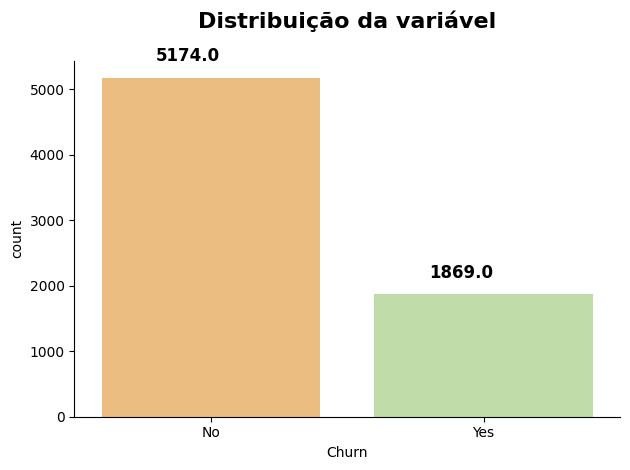

In [18]:
# checando a distribuição da variável alvo
print(df.Churn.value_counts())
print("\nChurn representa {:.2f}% do Dataset.\n".format((df[df.Churn == 'Yes'].shape[0] / df.shape[0]) * 100))

# plotando gráfico de barras
fig, ax = plt.subplots()
# Adotamos 'x' como o nome da coluna  e 'data' como o dataset
sns.countplot(x='Churn', data=df, ax=ax, palette='Spectral')
ax.set_title('Distribuição da variável', fontsize=16, fontweight='bold',pad=24)
for p in ax.patches:
    ax.annotate(f'\n{p.get_height()}', (p.get_x()+0.2, p.get_height()), xytext = (0, 12), textcoords = 'offset points', fontsize=12, fontweight='bold')

sns.despine(fig)
plt.tight_layout()
plt.show()

## **Entendendo o perfil dos clientes churn**

O principal objetivo deste experimento é identificar padrões que podem gerar rotatividade de clientes. Vamos nos concentrar na parte de rotatividade (1869 clientes) do conjunto de dados para a análise exploratória.

**1. Relatório resumido sobre atributos pessoaiss:**

Vamos revisar quais características pessoais mais contribuem para a decisão de cancelamento.

*Itens incluem: `Gender`, `Dependents`, `Partner`, `SeniorCitizen`*

*   **Não há insights relevantes** sobre gênero (49,7% masculino e 50,3% feminino)
*   **82%** dos clientes que cancelam o serviço não tinham dependentes. Clientes sem dependentes têm 4,7 vezes mais probabilidade de abandonar o negócio.
*   **74%** dos clientes não são Idosos. Os idosos têm 2,9 vezes menos probabilidade de abandonar o serviço.
*   **64%** dos clientes não possuíam sócios. Clientes com parceiros têm quase 1,7 vezes menos probabilidade de abandono.

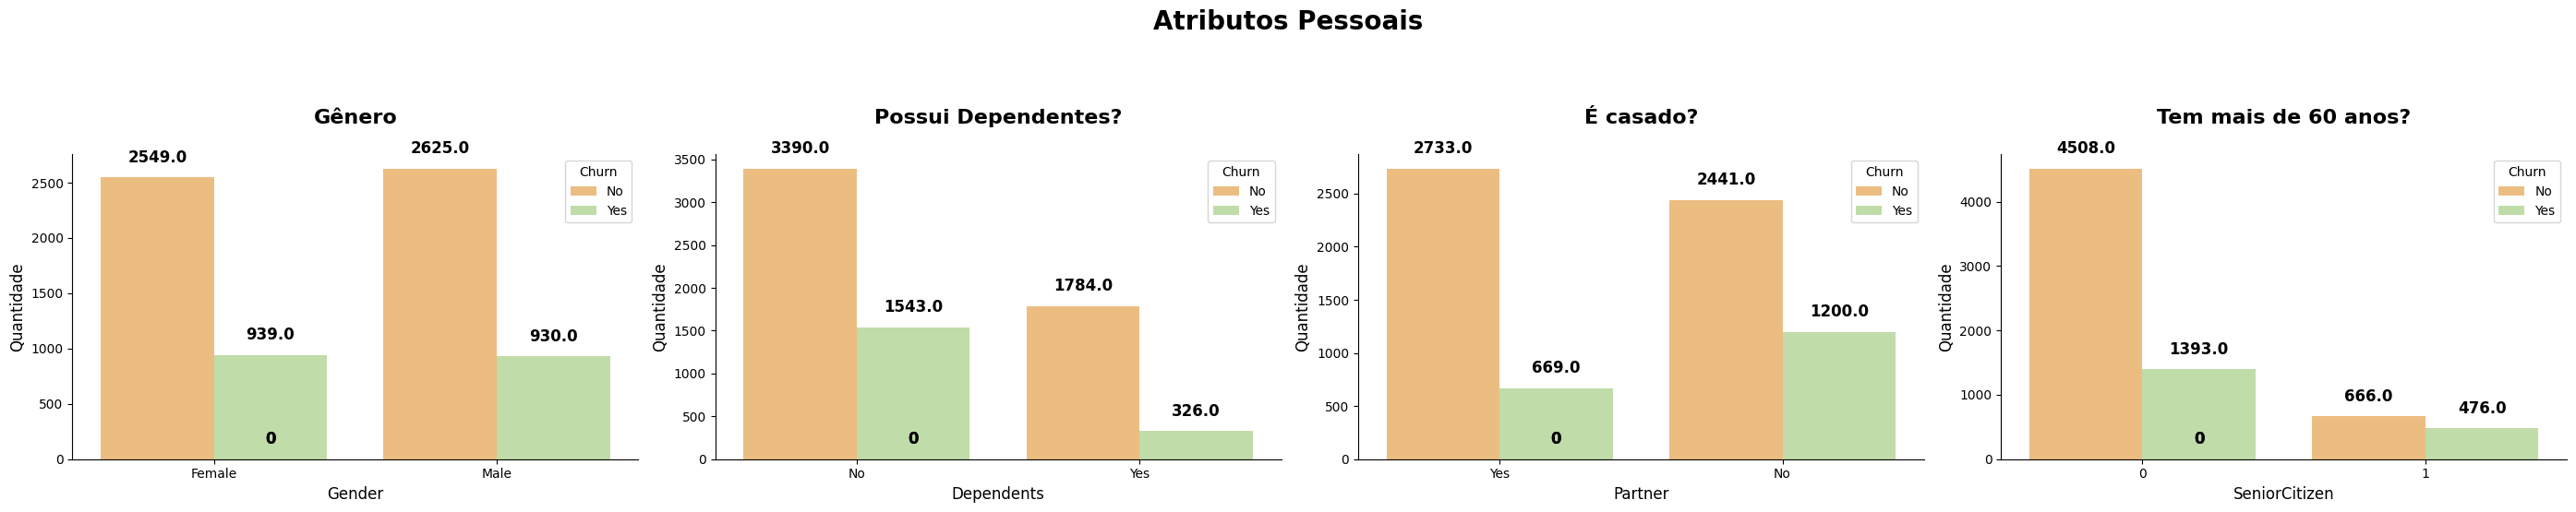

In [19]:
### Atributos Pessoais

f, axes = plt.subplots(1, 4,figsize=(28, 5))
f.suptitle('Atributos Pessoais',fontsize=20,fontweight='bold',y=1.1)

ax = sns.countplot(x="gender", hue="Churn", data=df, ax=axes[0], palette='Spectral')
ax.set_title('Gênero', fontsize=16, fontweight='bold',pad=24)
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Quantidade', fontsize=12)
for p in ax.patches:
    ax.annotate(f'\n{p.get_height()}', (p.get_x()+0.2, p.get_height()), ha='center', xytext = (0, 12), textcoords = 'offset points', fontsize=12, fontweight='bold')

ax1 = sns.countplot(x="Dependents", hue="Churn", data=df, ax=axes[1], palette='Spectral')
ax1.set_title('Possui Dependentes?', fontsize=16, fontweight='bold',pad=24)
ax1.set_xlabel('Dependents', fontsize=12)
ax1.set_ylabel('Quantidade', fontsize=12)
for p in ax1.patches:
    ax1.annotate(f'\n{p.get_height()}', (p.get_x()+0.2, p.get_height()), ha='center',xytext = (0, 12), textcoords = 'offset points', fontsize=12, fontweight='bold')

ax2 = sns.countplot(x="Partner", hue="Churn", data=df, ax=axes[2], palette='Spectral')
ax2.set_title('É casado?', fontsize=16, fontweight='bold',pad=24)
ax2.set_xlabel('Partner', fontsize=12)
ax2.set_ylabel('Quantidade', fontsize=12)
for p in ax2.patches:
    ax2.annotate(f'\n{p.get_height()}', (p.get_x()+0.2, p.get_height()), ha='center',xytext = (0, 12), textcoords = 'offset points', fontsize=12, fontweight='bold')

ax3 = sns.countplot(x="SeniorCitizen", hue="Churn", data=df, ax=axes[3], palette='Spectral')
ax3.set_title('Tem mais de 60 anos?', fontsize=16, fontweight='bold',pad=24)
ax3.set_xlabel('SeniorCitizen', fontsize=12)
ax3.set_ylabel('Quantidade', fontsize=12)
for p in ax3.patches:
    ax3.annotate(f'\n{p.get_height()}', (p.get_x()+0.2, p.get_height()), ha='center',xytext = (0, 12), textcoords = 'offset points', fontsize=12, fontweight='bold')

sns.despine(f)
plt.tight_layout()
plt.show()

**2. Relatório resumido sobre atributos de serviços:**

Vamos analisar quais características dos serviços mais contribuem para a decisão de cancelamento. Ele fornece informações sobre que tipo de serviço de operadora os clientes têm maior probabilidade de cancelar:

*Itens incluídos: `PhoneService`, `OnlineBackup`, `MultipleLines`, `InternetService`, `OnlineSecurity`*.

* **91%** dos clientes tinham um PhoneService habilitado.
* **66%** dos clientes não possuíam OnlineBackup.
* **69%** dos clientes tinham Fibra Óptica como serviço de internet.
* **78%** dos clientes não possuíam OnlineSecurity.

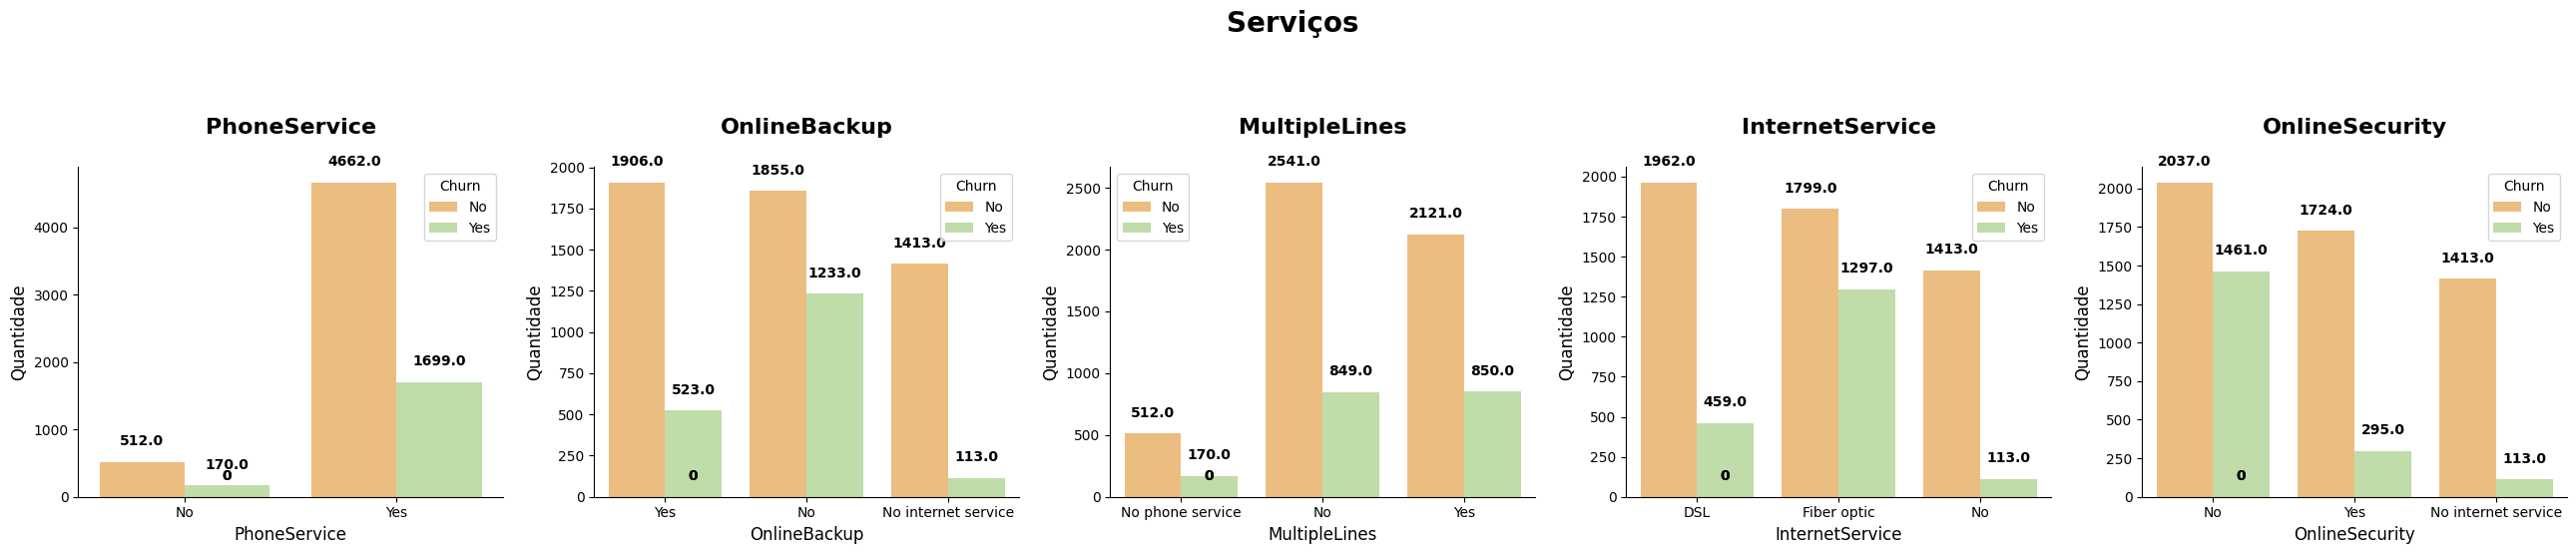

In [20]:
f, axes = plt.subplots(1, 5,figsize=(26, 5))
f.suptitle('Serviços',fontsize=20,fontweight='bold',y=1.1)

ax1 = sns.countplot(x="PhoneService", hue="Churn", data=df, ax=axes[0], palette='Spectral')
ax1.set_title('PhoneService', fontsize=16, fontweight='bold',pad=24)
ax1.set_xlabel('PhoneService', fontsize=12)
ax1.set_ylabel('Quantidade', fontsize=12)
for p in ax1.patches:
    ax1.annotate(f'\n{p.get_height()}', (p.get_x()+0.2, p.get_height()), ha='center', xytext = (0, 12), textcoords = 'offset points', fontsize=10, fontweight='bold')

ax2 = sns.countplot(x="OnlineBackup", hue="Churn", data=df, ax=axes[1], palette='Spectral')
ax2.set_title('OnlineBackup', fontsize=16, fontweight='bold',pad=24)
ax2.set_xlabel('OnlineBackup', fontsize=12)
ax2.set_ylabel('Quantidade', fontsize=12)
for p in ax2.patches:
    ax2.annotate(f'\n{p.get_height()}', (p.get_x()+0.2, p.get_height()), ha='center',xytext = (0, 12), textcoords = 'offset points', fontsize=10, fontweight='bold')

ax3 = sns.countplot(x="MultipleLines", hue="Churn", data=df, ax=axes[2], palette='Spectral')
ax3.set_title('MultipleLines', fontsize=16, fontweight='bold',pad=24)
ax3.set_xlabel('MultipleLines', fontsize=12)
ax3.set_ylabel('Quantidade', fontsize=12)
for p in ax3.patches:
    ax3.annotate(f'\n{p.get_height()}', (p.get_x()+0.2, p.get_height()), ha='center',xytext = (0, 12), textcoords = 'offset points', fontsize=10, fontweight='bold')

ax4 = sns.countplot(x="InternetService", hue="Churn", data=df, ax=axes[3], palette='Spectral')
ax4.set_title('InternetService', fontsize=16, fontweight='bold',pad=24)
ax4.set_xlabel('InternetService', fontsize=12)
ax4.set_ylabel('Quantidade', fontsize=12)
for p in ax4.patches:
    ax4.annotate(f'\n{p.get_height()}', (p.get_x()+0.2, p.get_height()), ha='center',xytext = (0, 12), textcoords = 'offset points', fontsize=10, fontweight='bold')

ax5 = sns.countplot(x="OnlineSecurity", hue="Churn", data=df, ax=axes[4], palette='Spectral')
ax5.set_title('OnlineSecurity', fontsize=16, fontweight='bold',pad=24)
ax5.set_xlabel('OnlineSecurity', fontsize=12)
ax5.set_ylabel('Quantidade', fontsize=12)
for p in ax5.patches:
    ax5.annotate(f'\n{p.get_height()}', (p.get_x()+0.2, p.get_height()), ha='center', xytext = (0, 12), textcoords = 'offset points', fontsize=10, fontweight='bold')

sns.despine(f)
plt.tight_layout()
plt.show()

**2. Relatório resumido sobre atributos de serviços:**

Continuando a revisão de quais características dos serviços mais contribuem para a decisão de cancelamento. Ele fornece informações sobre que tipo de serviço de operadora os clientes têm maior probabilidade de cancelar:

*Itens incluídos: `TechSupport`, `StreamingTV`, `StreamingMovies`, `DeviceProtection`*.

* **77%** dos clientes não possuíam TechSupport.
* **65%** dos clientes não tinham DeviceProtection.

Sobre os atributos de serviços, em geral, os clientes que não possuem os serviços de Segurança Online, Proteção de Dispositivos, Backup Online e Suporte Técnico habilitados têm maior probabilidade de sair.


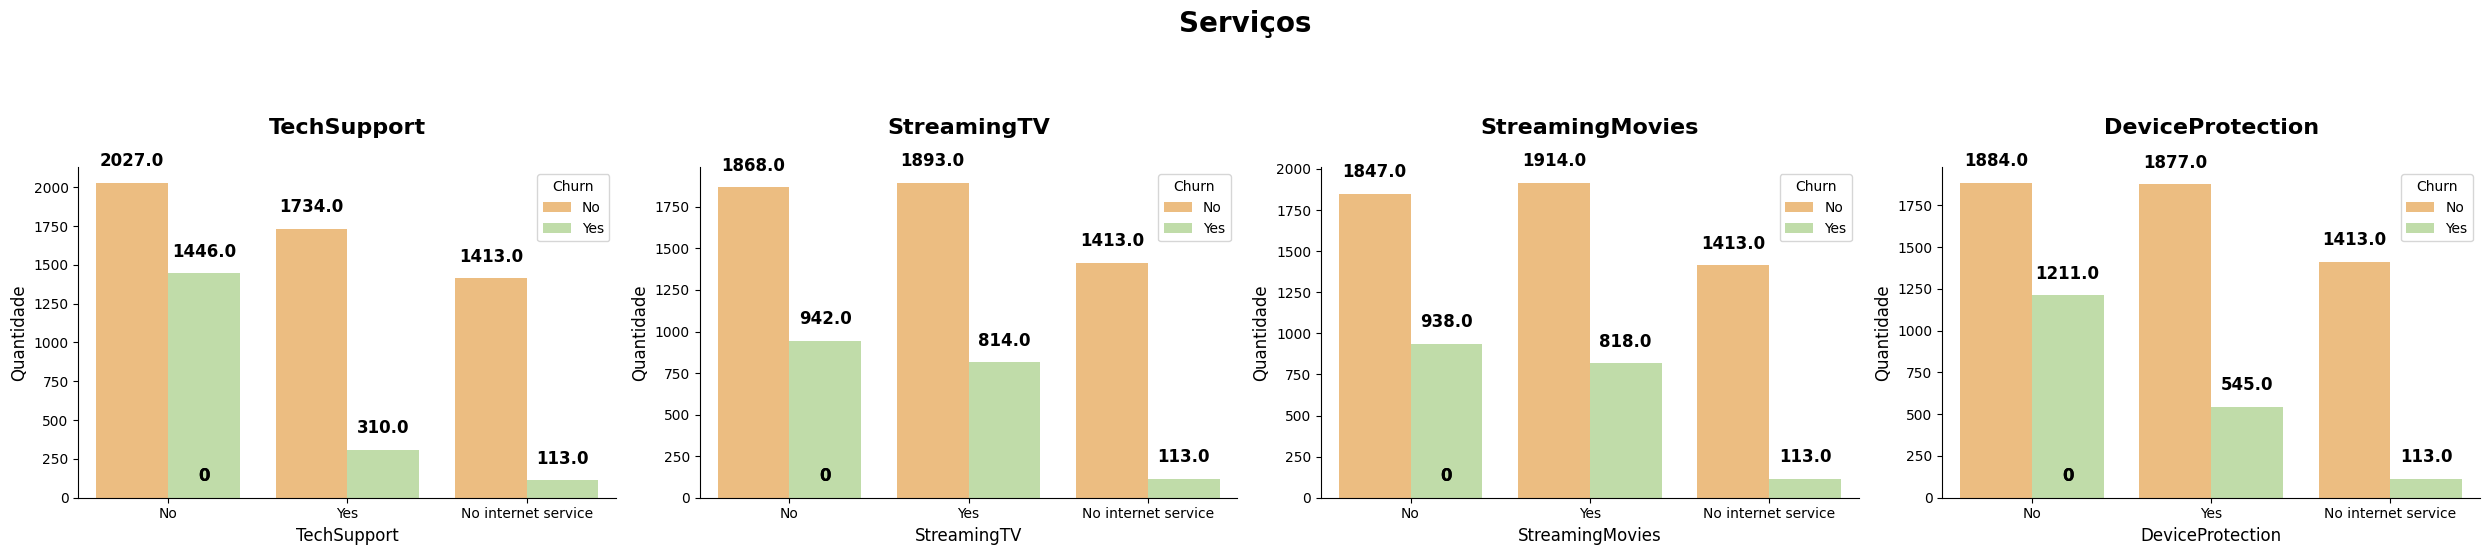

In [21]:
f, axes = plt.subplots(nrows=1, ncols=4,figsize=(25, 5))
f.suptitle('Serviços',fontsize=20,fontweight='bold',y=1.1)

ax = sns.countplot(x="TechSupport", hue="Churn", data=df, ax=axes[0], palette='Spectral')
ax.set_title('TechSupport', fontsize=16, fontweight='bold',pad=24)
ax.set_xlabel('TechSupport', fontsize=12)
ax.set_ylabel('Quantidade', fontsize=12)
for p in ax.patches:
    ax.annotate(f'\n{p.get_height()}', (p.get_x()+0.2, p.get_height()), ha='center', xytext = (0, 12), textcoords = 'offset points', fontsize=12, fontweight='bold')

ax1 = sns.countplot(x="StreamingTV", hue="Churn", data=df, ax=axes[1], palette='Spectral')
ax1.set_title('StreamingTV', fontsize=16, fontweight='bold',pad=24)
ax1.set_xlabel('StreamingTV', fontsize=12)
ax1.set_ylabel('Quantidade', fontsize=12)
for p in ax1.patches:
    ax1.annotate(f'\n{p.get_height()}', (p.get_x()+0.2, p.get_height()), ha='center',xytext = (0, 12), textcoords = 'offset points', fontsize=12, fontweight='bold')

ax2 = sns.countplot(x="StreamingMovies", hue="Churn", data=df, ax=axes[2], palette='Spectral')
ax2.set_title('StreamingMovies', fontsize=16, fontweight='bold',pad=24)
ax2.set_xlabel('StreamingMovies', fontsize=12)
ax2.set_ylabel('Quantidade', fontsize=12)
for p in ax2.patches:
    ax2.annotate(f'\n{p.get_height()}', (p.get_x()+0.2, p.get_height()), ha='center',xytext = (0, 12), textcoords = 'offset points', fontsize=12, fontweight='bold')

ax3 = sns.countplot(x="DeviceProtection", hue="Churn", data=df, ax=axes[3], palette='Spectral')
ax3.set_title('DeviceProtection', fontsize=16, fontweight='bold',pad=24)
ax3.set_xlabel('DeviceProtection', fontsize=12)
ax3.set_ylabel('Quantidade', fontsize=12)
for p in ax3.patches:
    ax3.annotate(f'\n{p.get_height()}', (p.get_x()+0.2, p.get_height()), ha='center',xytext = (0, 12), textcoords = 'offset points', fontsize=12, fontweight='bold')

sns.despine(f)
plt.tight_layout()
plt.show()

**3. Relatório resumido sobre o contrato:**

Vamos analisar quais características do contrato mais contribuem para a decisão de cancelamento.

*Itens incluídos: `PaperlessBilling`, `PaymentMethod` e `PaperlessBilling`*.

* **75%** dos clientes tinham o Faturamento Sem Papel habilitado.
* **57%** dos clientes tinham como forma de pagamento o Cheque Eletrônico.
* **88%** dos clientes tinham contrato do tipo mês a mês.

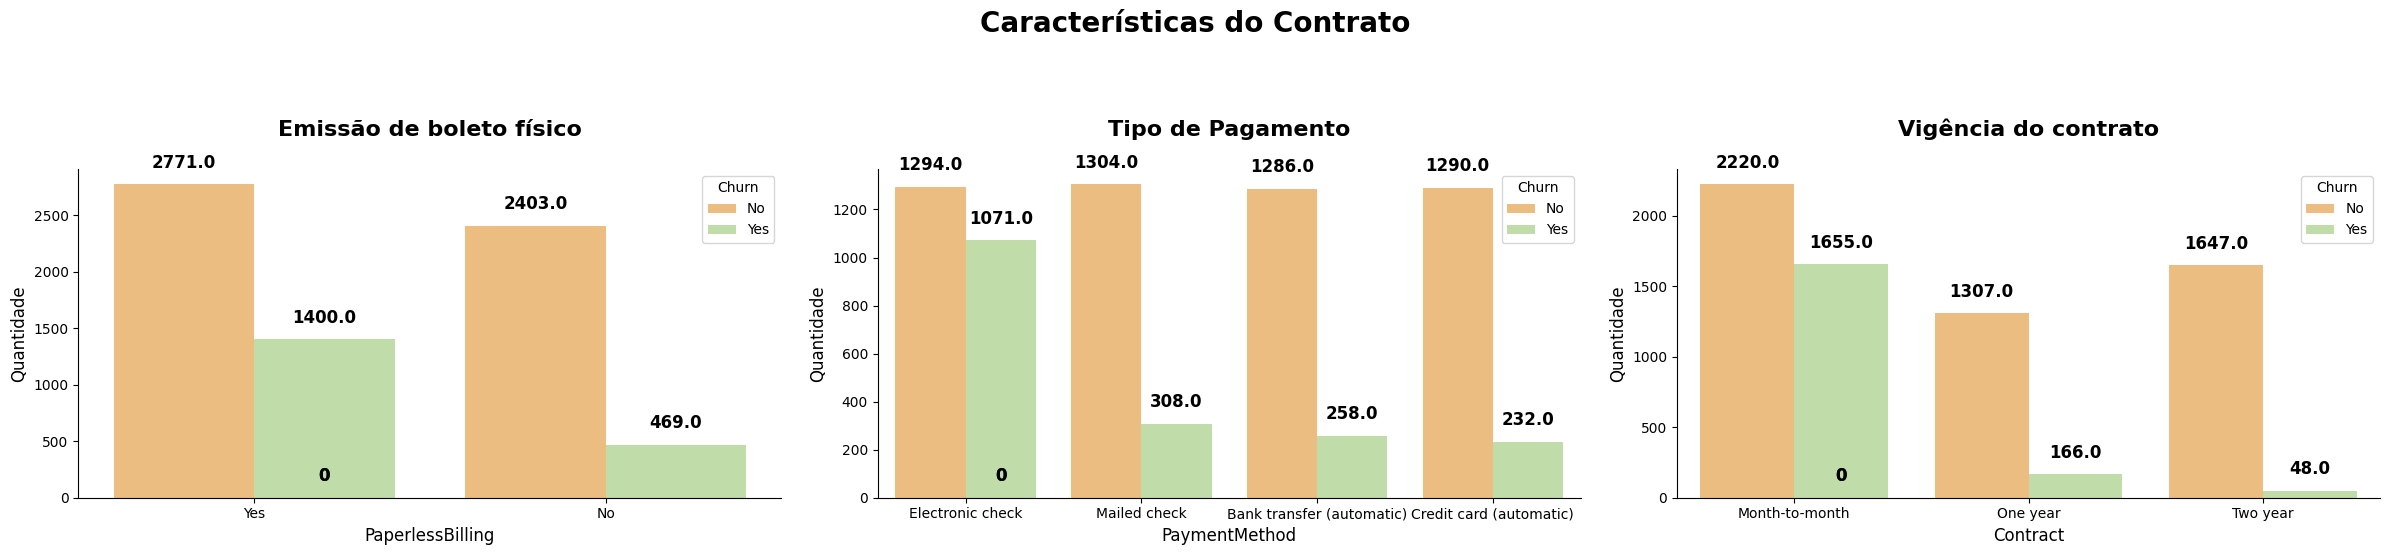

In [22]:
f, axes = plt.subplots(1, 3,figsize=(24, 5))
f.suptitle('Características do Contrato',fontsize=20,fontweight='bold',y=1.1)

ax1 = sns.countplot(x="PaperlessBilling", hue="Churn", data=df, ax=axes[0], palette='Spectral')
ax1.set_title('Emissão de boleto físico', fontsize=16, fontweight='bold',pad=24)
ax1.set_xlabel('PaperlessBilling', fontsize=12)
ax1.set_ylabel('Quantidade', fontsize=12)
for p in ax1.patches:
    ax1.annotate(f'\n{p.get_height()}', (p.get_x()+0.2, p.get_height()), ha='center', xytext = (0, 12), textcoords = 'offset points', fontsize=12, fontweight='bold')

ax2 = sns.countplot(x="PaymentMethod", hue="Churn", data=df, ax=axes[1], palette='Spectral')
ax2.set_title('Tipo de Pagamento', fontsize=16, fontweight='bold',pad=24)
ax2.set_xlabel('PaymentMethod', fontsize=12)
ax2.set_ylabel('Quantidade', fontsize=12)
for p in ax2.patches:
    ax2.annotate(f'\n{p.get_height()}', (p.get_x()+0.2, p.get_height()), ha='center',xytext = (0, 12), textcoords = 'offset points', fontsize=12, fontweight='bold')

ax3 = sns.countplot(x="Contract", hue="Churn", data=df, ax=axes[2], palette='Spectral')
ax3.set_title('Vigência do contrato', fontsize=16, fontweight='bold',pad=24)
ax3.set_xlabel('Contract', fontsize=12)
ax3.set_ylabel('Quantidade', fontsize=12)
for p in ax3.patches:
    ax3.annotate(f'\n{p.get_height()}', (p.get_x()+0.2, p.get_height()), ha='center',xytext = (0, 12), textcoords = 'offset points', fontsize=12, fontweight='bold')

sns.despine(f)
plt.tight_layout()
plt.show()

**4. Relatório resumido sobre a vida útil do cliente:**

A coluna permanência representa a quantidade de tempo que um cliente permanece dentro da empresa, o que significa que uma alta permanência representa alta fidelidade do cliente.

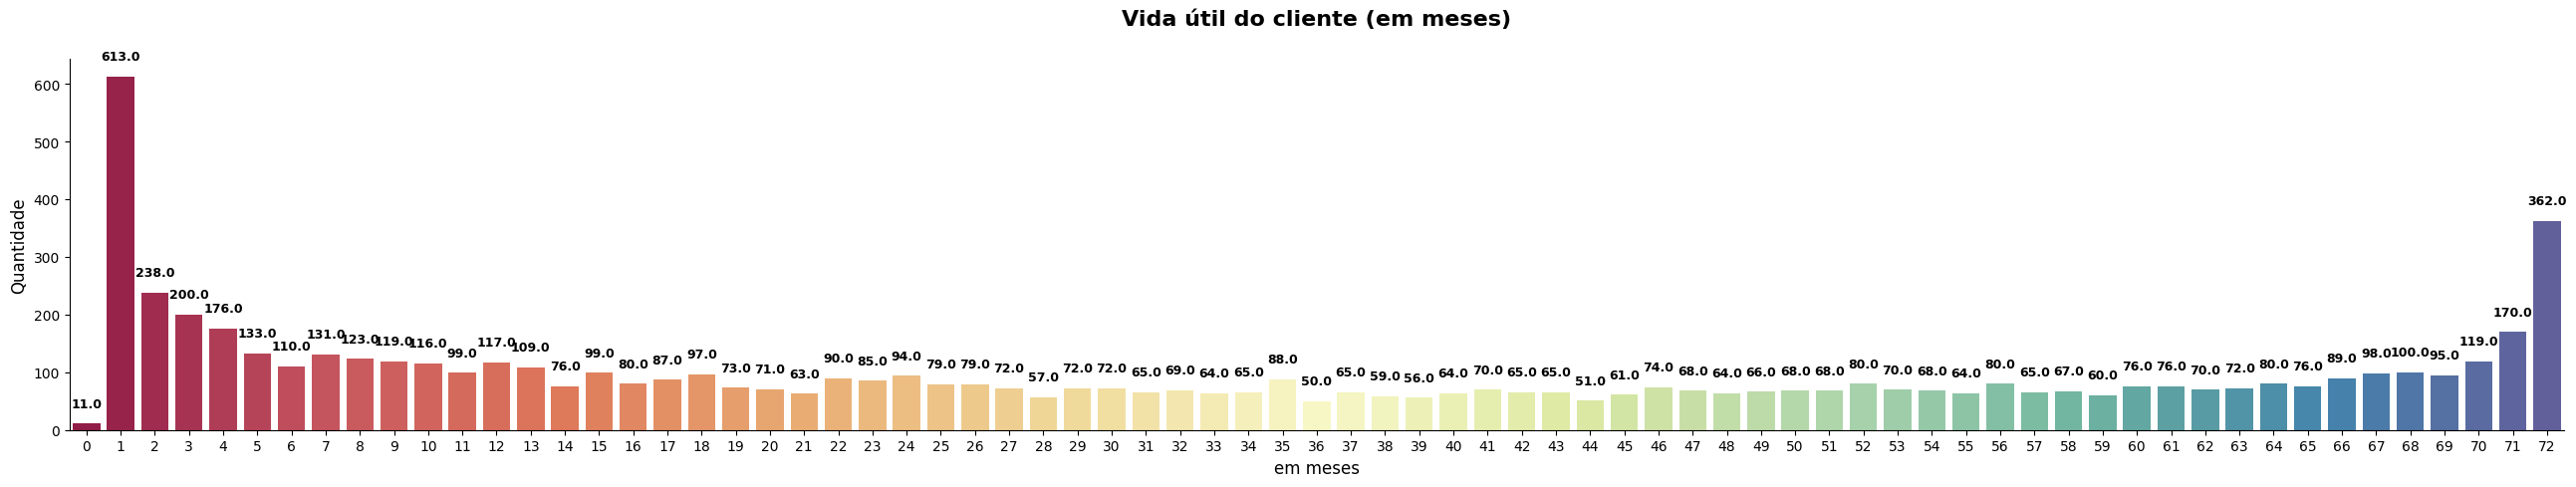

In [23]:
# Plotando o countplot para tenure
f, ax = plt.subplots(figsize=(26, 5))
ax = sns.countplot(x='tenure', data=df, ax=ax, palette='Spectral')
ax.set_title('Vida útil do cliente (em meses)', fontsize=16, fontweight='bold', pad=24)
ax.set_xlabel('em meses', fontsize=12)
ax.set_ylabel('Quantidade', fontsize=12)

# Adicionando os rótulos de quantidade nas barras
for p in ax.patches:
    ax.annotate(f'\n{p.get_height()}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', xytext=(0, 12), textcoords='offset points',
                fontsize=9, fontweight='bold')

sns.despine(f)
plt.tight_layout()
plt.show()

**Quanto tempo dura a vida útil do cliente até o cancelamento da assinatura?**

* **20%** dos clientes saem no primeiro mês.
* **32%** dos clientes saem até o terceiro mês.
* **42%** - quase a metade! - dos clientes permanecem até o sexto mês.

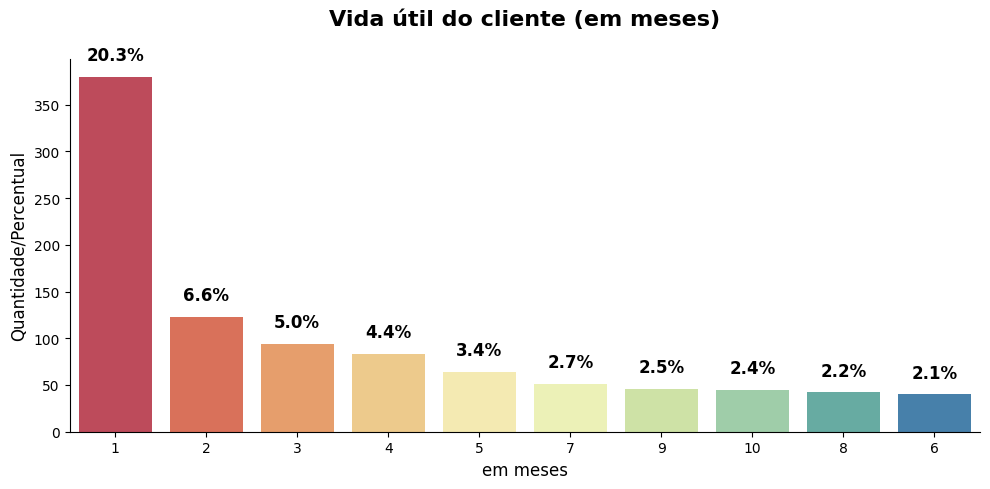

In [24]:
# Criando variáveis para calcular a porcentagem
df_top_churn = df[df['Churn'] == 'Yes']['tenure'].value_counts().sort_values(ascending=False).reset_index()
df_top_churn.columns = ['tenure', 'count']
total_churn = df[df['Churn'] == 'Yes'].shape[0]

# Configurando o gráfico
f, ax = plt.subplots(figsize=(10, 5))
ax = sns.barplot(x=df_top_churn['tenure'][:10], y=df_top_churn['count'][:10], ax=ax, palette='Spectral', order=df_top_churn['tenure'][:10])
ax.set_title('Vida útil do cliente (em meses)', fontsize=16, fontweight='bold', pad=24)
ax.set_xlabel('em meses', fontsize=12)
ax.set_ylabel('Quantidade/Percentual', fontsize=12)

# Adicionando as porcentagens
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total_churn)
    x = p.get_x() + p.get_width() / 2
    y = p.get_y() + p.get_height()
    ax.annotate(percentage, (x, y), ha='center', xytext=(0, 12), textcoords='offset points', fontsize=12, fontweight='bold')

sns.despine(f)
plt.tight_layout()
plt.show()

# **Preparação de dados**

## **Feature Engineering**

A *Feature engineering* é uma etapa importante para tratar, reformatar, enriquecer e calibrar dados para serem úteis aos modelos de aprendizado de máquina porque os algoritmos de ML só podem ler valores numéricos. Uma etapa importante na preparação de dados é aplicar a codificação de características categóricas em valores numéricos. Em nossos dados, tivemos alguns recursos categóricos com classes binárias, como `Gender`,`SeniorCitizen`,`Partner`,`Dependents`,`PhoneServices` e `PaperlessBilling`. Para eles podemos usar `le = LabelEncoder()` do Scikit-Learn para normalizar rótulos.

Para classes categóricas com mais de duas classes, `MultipleLines`, `InternetService` , `OnlineSecurity` , `OnlineBackup` , `DeviceProtection` , `TechSupport`, `StreamingTV` , `StreamingMovies` , `Contract` e `PaymentMethod` podemos use `pd.get_dummies()` do Pandas para converter essas classes em uma variável fictícia/indicadora.

In [25]:
# criando cópia do dataset
df_clean = df.copy()

# remover coluna costumerID
df_clean = df_clean.drop(['customerID'], axis=1)

# pré processar as variáveis
binary_var = df_clean.nunique()[df_clean.nunique() == 2].keys().tolist()
num_var = [col for col in df_clean.select_dtypes(['int', 'float']).columns.tolist() if col not in binary_var]
cat_var = [col for col in df_clean.columns.tolist() if col not in binary_var + num_var]

# criar uma cópia do dataframe
df_proc = df_clean.copy()

# Label Encoding para as variáveis Binárias
le = LabelEncoder()
for i in binary_var:
    df_proc[i] = le.fit_transform(df_proc[i])

# Encoding para colunas categóricas com múltiplas classes
df_proc = pd.get_dummies(df_proc, columns=cat_var)

# ver as 5 primeiras entradas do novo dataframe
df_proc.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,True,False,False,True,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,True,False,False,False,True,False,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,True,False,False,True,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,True,False,True,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,True,False,False,True,False,False,False,False,True,False


Depois de processar as etapas anteriores, podemos iniciar nosso modelo de aprendizado de máquina. Para comparar o desempenho e a melhoria do modelo, criamos uma linha de base simples. Nesta etapa não será feito nenhum ajuste de hiperparâmetros ou balanceamento de dados, por exemplo.

## **Dividir dados de treinamento e teste**

Antes de prosseguir com os dados do saldo, é um passo importante agora dividir os dados em duas partes: **conjunto de dados de treinamento** e **conjunto de dados de teste**, sem isso não temos parâmetros para verificar se o saldo estava correto. O **conjunto de dados de teste** será útil apenas na última etapa do projeto para nos dar uma melhor avaliação dos resultados. Este conjunto de dados de teste é o conjunto de dados final que usamos para medir o desempenho do modelo com base em algumas métricas. Para garantir que nosso conjunto de dados de treinamento e teste tenha a mesma quantidade de classes, proporcionalmente, usamos `stratify=y`.

* **Conjunto de dados desequilibrado**

In [27]:
# dividir variáveis ​​​​x e y
X = df_proc.drop(['Churn'], axis=1)
y = df_proc['Churn']

# dividir dataset entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, shuffle=True)

Usaremos a validação cruzada para estimar o erro da linha de base e o modelo inicial. Para nos ajudar, criaremos uma função `var_model` e definiremos `Recall` como nossa métrica de avaliação. Para o problema de churn, é a métrica ideal a ser utilizada. O recall responde à pergunta sobre qual proporção de positivos reais foi identificada corretamente? Essa métrica pode medir o percentual de churns que foram classificados corretamente em relação ao total de churns, que é o que buscamos para analisar o desempenho dos classificadores de ML.

In [28]:
def val_model(X, y, clf, quite=False):
    """
Faça validação cruzada para um determinado modelo

    # Arguments
      X: DataFrame, matriz de recursos
      y: Série, vetor alvo
      clf: classificador do scikit-learn
      quite: bool, indica se a função deve imprimir os resultados

    # Returns
      float, pontuações de validação
    """

    X = np.array(X)
    y = np.array(y)

    pipeline = make_pipeline(StandardScaler(), clf)
    scores = cross_val_score(pipeline, X, y, scoring='recall')

    if quite == False:
        print("Recall: {:.2f} (+/- {:.2f})".format(scores.mean(), scores.std()))

    return scores.mean()

Para a linha de base inicial, usaremos Random Forest, sem nenhuma alteração de parâmetro. Os dados usados ​​são os dados de treinamento.

In [29]:
# Crie uma linha de base inicial
rf = RandomForestClassifier()
score_baseline = val_model(X_train, y_train, rf)

Recall: 0.49 (+/- 0.02)


**Equilibrando e padronizando os dados**

Lembre-se, o balanceamento deve acontecer apenas com os dados de treinamento. Os dados de teste devem permanecer intactos.

Churn
0    1402
1    1402
Name: count, dtype: int64


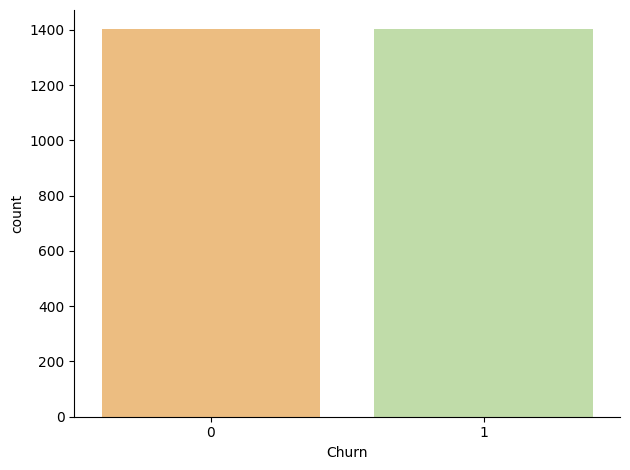

In [30]:
# Padronizando os dados
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)

# Under sampling
rus = RandomUnderSampler()
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# Certificando-se de que o número de classes está igualmente distribuído
print(pd.Series(y_train_rus).value_counts())

# Plotando a nova distribuição
sns.countplot(x=y_train_rus, palette='Spectral')
sns.despine()
plt.tight_layout()
plt.show()


#**Modelo de aprendizado de máquina**

## **Instanciar modelos**

Crie uma linha de base usando validação cruzada com um conjunto de dados de treinamento. Serão utilizados neste projeto os algoritmos anteriores:

* Random Forest
* Decision Tree
* Stochastic Gradient Descent
* SVC
* Regressão Logística
* LightGBM

Após o script, podemos ver uma tabela intuitiva com os resultados do Recall para cada um. Definiremos qual modelo é melhor para atender aos requisitos para resolver este problema.

Após a preparação dos dados, uma análise exploratória profunda iremos instaciar modelos e treinar com dados `X_rus` e `y_rus`. Posteriormente, faremos previsões com dados de teste.

In [31]:
# instanciar modelos
rf = RandomForestClassifier()
dt = DecisionTreeClassifier()
sgdc = SGDClassifier()
svc = SVC()
lr = LogisticRegression()
xgb = XGBClassifier()
lgbm = LGBMClassifier()

model = []
recall = []
# Calculando Recall
for clf in (rf, dt, sgdc, svc, lr, xgb, lgbm):
    model.append(clf.__class__.__name__)
    recall.append(val_model(X_train_rus, y_train_rus, clf, quite=True))

pd.DataFrame(data=recall, index=model, columns=['Recall'])

[LightGBM] [Info] Number of positive: 1122, number of negative: 1121
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001153 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 694
[LightGBM] [Info] Number of data points in the train set: 2243, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500223 -> initscore=0.000892
[LightGBM] [Info] Start training from score 0.000892
[LightGBM] [Info] Number of positive: 1122, number of negative: 1121
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000968 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 694
[LightGBM] [Info] Number of data points in the train set: 2243, number of used features: 40
[LightGBM] [Info] [binary:Bo

,Recall
RandomForestClassifier,0.756805
DecisionTreeClassifier,0.667616
SGDClassifier,0.747623
SVC,0.788172
LogisticRegression,0.800308
XGBClassifier,0.754644
LGBMClassifier,0.773177


Pelas características do problema e do desempenho durante as execuções anteriores, foi optado pelos modelos XGBoost, Regressão Logística e SVM para ajuste de parâmetros.

Na minha opinião, **Modelos de ajuste** podem melhorar ainda mais as qualidades desses modelos.

## **Otimização de hiperparâmetros**

### **XGBoost**

XGBoost possui vários parâmetros. Alguns afetam mais a qualidade do modelo, outros menos. Uma boa prática é definir uma taxa de aprendizagem e um número de estimadores, realizar o ajuste de outros parâmetros e, ao final, verificar outras taxas de aprendizagem.

A seguir, ajustaremos cada parâmetro passo a passo para ajudar em nosso entendimento.

Como pode ser visto abaixo apresentou uma ligeira melhora após o ajuste, aumentando o Recall de **0,79** para **0,89**.

In [32]:
# obter parâmetros
print(xgb.get_params().keys())

dict_keys(['objective', 'base_score', 'booster', 'callbacks', 'colsample_bylevel', 'colsample_bynode', 'colsample_bytree', 'device', 'early_stopping_rounds', 'enable_categorical', 'eval_metric', 'feature_types', 'gamma', 'grow_policy', 'importance_type', 'interaction_constraints', 'learning_rate', 'max_bin', 'max_cat_threshold', 'max_cat_to_onehot', 'max_delta_step', 'max_depth', 'max_leaves', 'min_child_weight', 'missing', 'monotone_constraints', 'multi_strategy', 'n_estimators', 'n_jobs', 'num_parallel_tree', 'random_state', 'reg_alpha', 'reg_lambda', 'sampling_method', 'scale_pos_weight', 'subsample', 'tree_method', 'validate_parameters', 'verbosity'])


In [33]:
xgb = XGBClassifier()

param_grid = {
 'n_estimators':range(0,1000,50),
}

#  Verificando o melhor parâmetro
kfold = StratifiedKFold(n_splits=10, shuffle=True)
grid_search = GridSearchCV(xgb, param_grid, scoring="recall", n_jobs=-1, cv=kfold)
grid_result = grid_search.fit(X_train_rus, y_train_rus)

# Verificando resultados
print("Melhor recall: {} de {}".format(grid_result.best_score_, grid_result.best_params_))

Melhor recall: 0.756079027355623 de {'n_estimators': 50}


In [34]:
xgb = XGBClassifier(n_estimators=50)

param_grid = {
 'max_depth': [1,8,1],
 'min_child_weight':[1,5,1],
}

# Verificando o melhor parâmetro
kfold = StratifiedKFold(n_splits=10, shuffle=True)
grid_search = GridSearchCV(xgb, param_grid, scoring="recall", n_jobs=-1, cv=kfold)
grid_result = grid_search.fit(X_train_rus, y_train_rus)

# Verificando resultados
print("Melhor Recall: {} de {}".format(grid_result.best_score_, grid_result.best_params_))

Melhor Recall: 0.815243161094225 de {'max_depth': 1, 'min_child_weight': 1}


In [35]:
xgb = XGBClassifier(n_estimators=50, min_child_weight=1, max_depth=1)

param_grid = {
  "learning_rate": [0.001, 0.01, 0.1, 1],
}

# Verificando o melhor parâmetro
kfold = StratifiedKFold(n_splits=10, shuffle=True)
grid_search = GridSearchCV(xgb, param_grid, scoring="recall", n_jobs=-1, cv=kfold)
grid_result = grid_search.fit(X_train_rus, y_train_rus)

# Verificando resultados
print("Melhor Recall: {} de {}".format(grid_result.best_score_, grid_result.best_params_))

Melhor Recall: 0.8851266464032422 de {'learning_rate': 0.001}


Após ajustar os parâmetros, treinaremos o modelo com o conjunto de dados de treinamento completo e verificaremos o desempenho final com esses “novos dados” que foram preservados.

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples

              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1294
           1       0.00      0.00      0.00       467

    accuracy                           0.73      1761
   macro avg       0.37      0.50      0.42      1761
weighted avg       0.54      0.73      0.62      1761

AUC: 0.5000



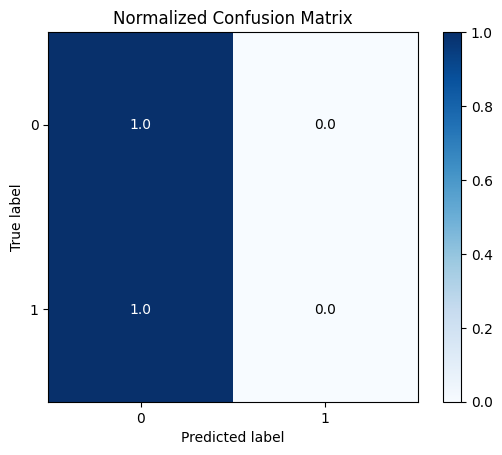

In [49]:
# Modelo final
model_xgb = XGBClassifier(learning_rate=0.001 , n_estimators=50, max_depth=1, min_child_weight=1)
model_xgb.fit(X_train_rus, y_train_rus)

# Fazendo previsão
X_test = scaler.transform(X_test)
y_pred_model_xgb = model_xgb.predict(X_test)

# Relatório de Classificação
print(classification_report(y_test, y_pred_model_xgb))

# Imprimindo AUC
print("AUC: {:.4f}\n".format(roc_auc_score(y_test, y_pred_model_xgb)))

# Plotando a matriz confusão
plot_confusion_matrix(y_test, y_pred_model_xgb, normalize=True)
plt.show()


### **Regressão Logística**

Como pode ser visto abaixo apresentou uma ligeira melhora após o ajuste, aumentando o Recall de **0,79** para **0,85**.

In [37]:
# Obter parâmetros
print(lr.get_params().keys())

dict_keys(['C', 'class_weight', 'dual', 'fit_intercept', 'intercept_scaling', 'l1_ratio', 'max_iter', 'multi_class', 'n_jobs', 'penalty', 'random_state', 'solver', 'tol', 'verbose', 'warm_start'])


In [38]:
lr = LogisticRegression()

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

# Verificando o melhor parâmetro
kfold = StratifiedKFold(n_splits=10, shuffle=True)
grid_search = GridSearchCV(lr, param_grid, scoring="recall", n_jobs=-1, cv=kfold)
grid_result = grid_search.fit(X_train_rus, y_train_rus)

# Verificando resultados
print("Melhor Recall: {} for {}".format(grid_result.best_score_, grid_result.best_params_))

Melhor Recall: 0.8031205673758866 for {'C': 100}


In [40]:
lr = LogisticRegression(C=0.001)

param_grid = {"solver": ["newton-cg", "lbfgs", "liblinear",'sag','saga']
}

# Verificando o melhor parâmetro
kfold = StratifiedKFold(n_splits=10, shuffle=True)
grid_search = GridSearchCV(lr, param_grid, scoring="recall", n_jobs=-1, cv=kfold)
grid_result = grid_search.fit(X_train_rus, y_train_rus)

# Verificando os resultados
print("Melhor Recall: {} de {}".format(grid_result.best_score_, grid_result.best_params_))

Melhor Recall: 0.8367325227963527 de {'solver': 'liblinear'}


In [41]:
# Define o modelo
lr = LogisticRegression(C=0.001, solver='liblinear')

# Ajusta o grid de parâmetros
param_grid = {"penalty": ["l1", "l2"]}

# Realiza a busca pelo melhor parâmetro
kfold = StratifiedKFold(n_splits=10, shuffle=True)
grid_search = GridSearchCV(lr, param_grid, scoring="recall", n_jobs=-1, cv=kfold)
grid_result = grid_search.fit(X_train_rus, y_train_rus)

# Exibe os resultados
print("Melhor Recall: {} de {}".format(grid_result.best_score_, grid_result.best_params_))

Melhor Recall: 0.8373252279635258 de {'penalty': 'l2'}


In [42]:
# Define o modelo com o solver 'saga'
lr = LogisticRegression(C=0.001, solver='saga', penalty='l2')

# Define o grid de parâmetros
param_grid = {
    'multi_class': ['ovr', 'multinomial', 'auto']
}

# Realiza a busca pelo melhor parâmetro
kfold = StratifiedKFold(n_splits=10, shuffle=True)
grid_search = GridSearchCV(lr, param_grid, scoring="recall", n_jobs=-1, cv=kfold)
grid_result = grid_search.fit(X_train_rus, y_train_rus)

# Exibe os resultados
print("Melhor Recall: {} de {}".format(grid_result.best_score_, grid_result.best_params_))

Melhor Recall: 0.8017578520770009 de {'multi_class': 'ovr'}


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.92      0.63      0.75      1294
           1       0.45      0.85      0.59       467

    accuracy                           0.69      1761
   macro avg       0.69      0.74      0.67      1761
weighted avg       0.80      0.69      0.71      1761

AUC: 0.7386



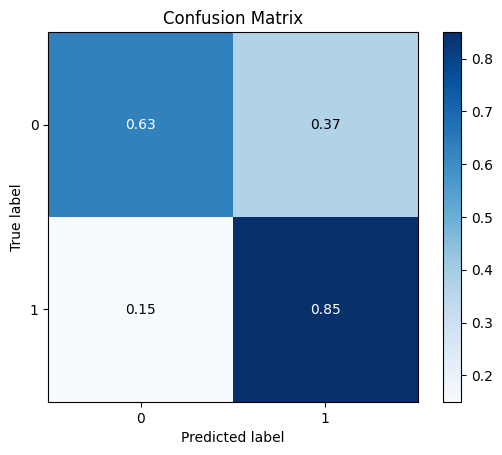

In [43]:
# Modelo final
model_lr = LogisticRegression(C=0.001, solver='liblinear', penalty='l2', multi_class='ovr')
model_lr.fit(X_train_rus, y_train_rus)

# Padronizando os dados de teste
X_test = scaler.transform(X_test)

# Fazendo previsões
y_pred_model_lr = model_lr.predict(X_test)

# Relatório de classificação
print(classification_report(y_test, y_pred_model_lr))

# Calculando e imprimindo AUC
print("AUC: {:.4f}\n".format(roc_auc_score(y_test, y_pred_model_lr)))

# Plotando a matriz de confusão
model_lr_corr = plot_confusion_matrix(y_test, y_pred_model_lr, normalize=True)
plt.title('Confusion Matrix')
plt.show()

### **SVM**

Como pode ser visto abaixo ele não apresentou melhora após o ajuste, mantendo Recall semelhante entre **0,78** e **0,77**. Tentaremos aprofundar e melhorar nosso parâmetro de ajuste em um momento oportuno no futuro.

In [44]:
# obter parâmetros
print(svc.get_params().keys())

dict_keys(['C', 'break_ties', 'cache_size', 'class_weight', 'coef0', 'decision_function_shape', 'degree', 'gamma', 'kernel', 'max_iter', 'probability', 'random_state', 'shrinking', 'tol', 'verbose'])


In [45]:
svc = SVC()

param_grid = {'C' :  [0.001, 0.01, 1, 10, 100] ,
}

# Verificando o melhor parâmetro
kfold = StratifiedKFold(n_splits=10, shuffle=True)
grid_search = GridSearchCV(svc, param_grid, scoring="recall", cv=kfold)
grid_result = grid_search.fit(X_train_rus, y_train_rus)

# ver resultados
print("Melhor Recall: {} de {}".format(grid_result.best_score_, grid_result.best_params_))

Melhor Recall: 0.7810486322188449 de {'C': 0.01}


In [46]:
svc = SVC(C=0.01)

param_grid = {'kernel' :  ['linear', 'poly', 'rbf', 'sigmoid']
}

# Verificando o melhor parâmetro
kfold = StratifiedKFold(n_splits=10, shuffle=True)
grid_search = GridSearchCV(svc, param_grid, scoring="recall", cv=kfold)
grid_result = grid_search.fit(X_train_rus, y_train_rus)

# ver resultados
print("Melhor Recall: {} de {}".format(grid_result.best_score_, grid_result.best_params_))

Melhor Recall: 0.93080547112462 de {'kernel': 'poly'}


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.90      0.69      0.78      1294
           1       0.48      0.80      0.60       467

    accuracy                           0.72      1761
   macro avg       0.69      0.74      0.69      1761
weighted avg       0.79      0.72      0.73      1761

AUC: 0.7433



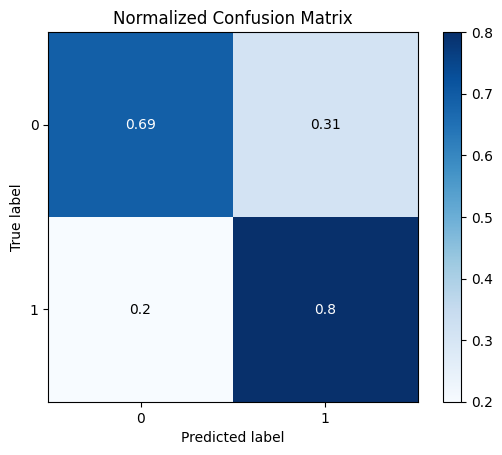

In [47]:
# Modelo final
model_svm = SVC(kernel='poly', C= 0.01)
model_svm.fit(X_train_rus, y_train_rus)

# Fazedo previsões
X_test = scaler.transform(X_test)
y_pred_model_svm = model_svm.predict(X_test)

# Reportando Classific ação
print(classification_report(y_test, y_pred_model_svm))

# Imprimindo AUC
print("AUC: {:.4f}\n".format(roc_auc_score(y_test, y_pred_model_svm)))

# Plotando o gráfico de matriz de confusão
plot_confusion_matrix(y_test, y_pred_model_svm, normalize=True)
plt.show()


**Comparando os modelos XGB, LR e SVM**

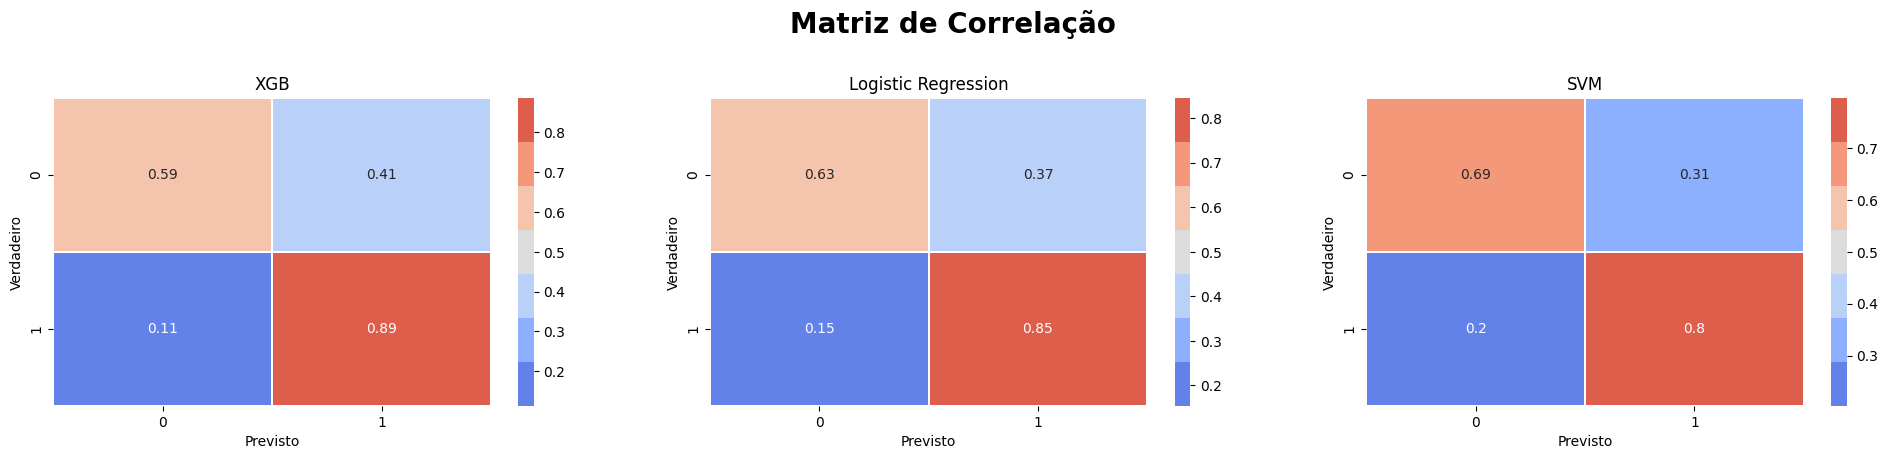

In [48]:
palette = sns.color_palette("coolwarm", 7)

xgb_corr = confusion_matrix(y_test, y_pred_model_xgb, normalize='true')
lr_corr = confusion_matrix(y_test, y_pred_model_lr, normalize='true')
svm_corr = confusion_matrix(y_test, y_pred_model_svm, normalize='true')

f, ax = plt.subplots(nrows=1, ncols=3, figsize = (24,4))
f.suptitle('Matriz de Correlação',fontsize=20,fontweight='bold',y=1.1)

sns.heatmap(xgb_corr, annot=True, linewidths=.1, cmap=palette, ax=ax[0])
ax[0].set_title('XGB')
ax[0].set_ylabel('Verdadeiro')
ax[0].set_xlabel('Previsto')

sns.heatmap(lr_corr, annot=True, linewidths=.1, cmap=palette, ax=ax[1])
ax[1].set_title('Logistic Regression')
ax[1].set_ylabel('Verdadeiro')
ax[1].set_xlabel('Previsto')

sns.heatmap(svm_corr, annot=True, linewidths=.1, cmap=palette, ax=ax[2])
ax[2].set_title('SVM')
ax[2].set_ylabel('Verdadeiro')
ax[2].set_xlabel('Previsto')


plt.show()

# **Conclusão**

Nenhum algoritmo detectará a rotatividade com 100% de precisão. Sempre haverá uma compensação entre a métrica de precisão e a métrica de recall. Por isso é importante testar e ter um conhecimento profundo do negócio, dos dados e dos pontos fortes e fracos de cada classificador para tirar o melhor proveito de cada um.

Foi escolhido o **modelo XGB** porque o Recall é melhor que outros modelos testados, com **0,89** e apesar da precisão ser de **0,41**
um pouco maior que a Regressão Logística. É aceitável engajar e oferecer algo àqueles que são erroneamente rotulados como ‘*not churned*’, pois isso não causa nenhum impacto negativo na marca.